In [1]:
import pandas as pd
import numpy as np
import warnings
import data_loader as data_loader
from feature_engineering import FeatureProcessor, TargetProcessor

print("libraries imported")

warnings.filterwarnings('ignore')


libraries imported


In [2]:
raw_df = data_loader.build_merged_dataset()
df = data_loader.preprocess_merged_df(raw_df)
df = df[df.index >= '2020-01-01']

Loading CSV files...
Aligning to BTC 7x24 timeline...
Merging all assets...
Adding US market trading hours flag...
Done! Final shape: (2999498, 29)


<Axes: ylabel='Timestamp'>

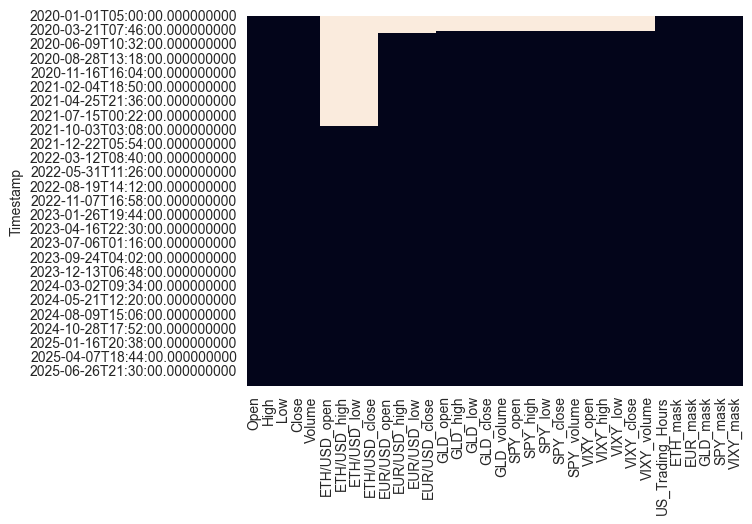

In [3]:
import seaborn as sns
sns.heatmap(df.isna(), cbar=False)

In [4]:
# get target
tp = TargetProcessor(price_col='Close', window=30)
btc_target, target_cols = tp.fit_transform(df)

# process features
fp = FeatureProcessor(rolling_smooth=60)
btc = fp.process_all(btc_target)

print(btc.shape)
print(btc.columns.values)

(2101506, 138)
['Open' 'High' 'Low' 'Close' 'Volume' 'ETH/USD_open' 'ETH/USD_high'
 'ETH/USD_low' 'EUR/USD_open' 'EUR/USD_high' 'EUR/USD_low' 'GLD_open'
 'GLD_high' 'GLD_low' 'GLD_volume' 'SPY_open' 'SPY_high' 'SPY_low'
 'SPY_volume' 'VIXY_open' 'VIXY_high' 'VIXY_low' 'VIXY_volume'
 'US_Trading_Hours' 'ETH_mask' 'EUR_mask' 'GLD_mask' 'SPY_mask'
 'VIXY_mask' 'target_log_return' 'target_cum_return_30m' 'target_binary'
 'target_log_return_norm' 'target_cum_return_30m_norm' 'ETH/USD_close_ret'
 'EUR/USD_close_ret' 'GLD_close_ret' 'SPY_close_ret' 'VIXY_close_ret'
 'Open_lag1' 'Open_lag2' 'Open_lag3' 'Open_lag5' 'Open_lag10' 'Open_lag15'
 'Open_lag30' 'High_lag1' 'High_lag2' 'High_lag3' 'High_lag5' 'High_lag10'
 'High_lag15' 'High_lag30' 'Low_lag1' 'Low_lag2' 'Low_lag3' 'Low_lag5'
 'Low_lag10' 'Low_lag15' 'Low_lag30' 'Close_lag1' 'Close_lag2'
 'Close_lag3' 'Close_lag5' 'Close_lag10' 'Close_lag15' 'Close_lag30'
 'Volume_lag1' 'Volume_lag2' 'Volume_lag3' 'Volume_lag5' 'Volume_lag10'
 'Volume_l

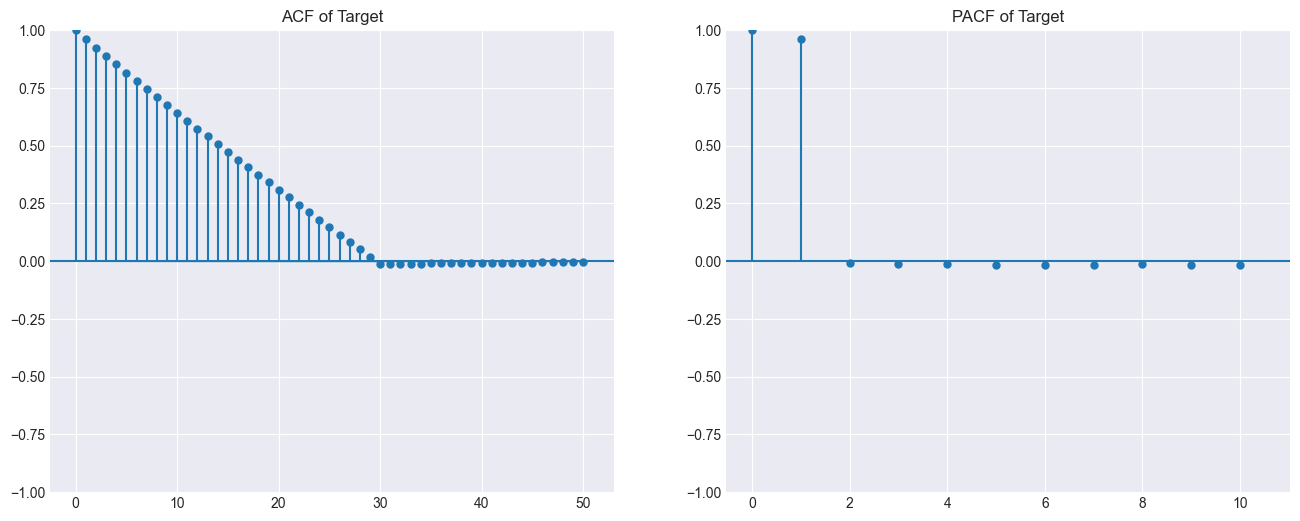

In [5]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12.0, 6.0]

fig, axes = plt.subplots(1, 2, figsize = (16,6))
plot_acf(btc['target_cum_return_30m_norm'], lags = 50, ax = axes[0], title = 'ACF of Target')
plot_pacf(btc['target_cum_return_30m_norm'], lags = 10, ax = axes[1], title = 'PACF of Target')
plt.show()

In [6]:
def create_sequences(X, y, seq_len=30):
    X_values = X.values if isinstance(X, pd.DataFrame) else X
    y_values = y.values if isinstance(y, (pd.DataFrame, pd.Series)) else y
    y_values = y_values.ravel()

    num_samples = len(X_values) - seq_len
    X_seq = np.zeros((num_samples, seq_len, X_values.shape[1]), dtype=np.float32)
    y_seq = np.zeros((num_samples, 1), dtype=np.float32)

    for i in range(num_samples):
        X_seq[i] = X_values[i:i+seq_len]
        y_seq[i, 0] = y_values[i + seq_len]  # predict next step

    return X_seq, y_seq

In [7]:


FEATURES_CONT = [
    # --- Price Lags  ---
    'Close_lag1', 'Close_lag2', 'Close_lag5', 'Close_lag10', 'Close_lag30',

    # --- Cross-Asset Returns  ---
    'ETH/USD_close_ret_lag1', 'ETH/USD_close_ret_lag3',
    'EUR/USD_close_ret_lag1',
    'GLD_close_ret_lag1',
    'SPY_close_ret_lag1',
    'VIXY_close_ret_lag1', 'VIXY_close_ret_lag3',

    # --- Volume & Volatility  ---
    'log_volume',
    'Volume_lag1', 'Volume_lag3',
    'vol_ratio',
    'price_vol_trend',

    # --- VWAP & Structure  ---
    'dist_vwap', 'VWSDEV',
    'candle_range', 'shadow_upper', 'shadow_lower',

    # --- Technical Indicators  ---
    'RSI7', 'MACD_Line', 'MACD_Signal'
]

FEATURES_CAT = [
    'US_Trading_Hours'
]

# ---------------------------------------------------------
# ---------------------------------------------------------
def rolling_zscore_matrix(df, feature_cols, window=60, eps=1e-8):

    X_vals = df[feature_cols].values


    cumsum = np.cumsum(np.vstack([np.zeros(X_vals.shape[1]), X_vals]), axis=0)
    cumsum2 = np.cumsum(np.vstack([np.zeros(X_vals.shape[1]), X_vals**2]), axis=0)

    mean = (cumsum[window:] - cumsum[:-window]) / window
    mean2 = (cumsum2[window:] - cumsum2[:-window]) / window


    var = np.maximum(mean2 - mean**2, eps)
    std = np.sqrt(var)

    # Z-score
    zscore = (X_vals[window-1:] - mean) / std


    index = df.index[window-1:]
    return pd.DataFrame(zscore, index=index, columns=feature_cols)

# ---------------------------------------------------------
# pipeline
# ---------------------------------------------------------

# ⚙️ Step 1: Rolling Z-score
window = 60
print(f"Applying Rolling Z-Score (window={window})...")
X_cont_scaled = rolling_zscore_matrix(btc, FEATURES_CONT, window=window)

# ⚙️ Step 2:
#
X_cat = btc[FEATURES_CAT].loc[X_cont_scaled.index].copy()

# ⚙️ Step 3:
X = pd.concat([X_cont_scaled, X_cat], axis=1)

#
X = X.replace([np.inf, -np.inf], 0).fillna(0)

# ---------------------------------------------------------
# Target
# ---------------------------------------------------------
y = btc['target_cum_return_30m_norm'].copy()

y = y.loc[X.index]

# max Target

TARGET_SCALE = 100.0
y = y * TARGET_SCALE

# ---------------------------------------------------------
# 5️⃣ final check
# ---------------------------------------------------------
print("-" * 30)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features used: {len(X.columns)}")
print(f"Target example (first 5): \n{y.head().values}")
print(f"Feature statistics (mean should be ~0): \n{X[FEATURES_CONT[0]].head()}")
print("-" * 30)




Applying Rolling Z-Score (window=60)...
------------------------------
X shape: (2101447, 26)
y shape: (2101447,)
Features used: 26
Target example (first 5): 
[-8.75678991 22.0847093  44.66126308 18.48948189 36.31944379]
Feature statistics (mean should be ~0): 
Timestamp
2021-09-13 07:24:00-04:00   -2.635185
2021-09-13 07:25:00-04:00   -2.455393
2021-09-13 07:26:00-04:00   -2.658253
2021-09-13 07:27:00-04:00   -2.956525
2021-09-13 07:28:00-04:00   -2.768829
Name: Close_lag1, dtype: float64
------------------------------


In [8]:
FINAL_MODEL = None
SCALER = None
Y_SCALER = None
HISTORY_BUFFER = None
PREV_RETURN = None
FEATURE_COLUMNS = [
 #'GLD_volume',
 'ETH/USD_high',
 #'EUR/USD_close_ret_lag2',
 'RSI21',
 'vol_ratio',
 'body_size',
 'shadow_lower',
 #'ETH/USD_close_ret_lag15',
 #'EUR/USD_close_ret_lag1'
]
TARGET_COLUMN = "target_cum_return_30m_norm"

SEQUENCE_LENGTH = 90 #30

In [9]:
TEST_DAYS = 14
test_len = TEST_DAYS * 1440
split_index = len(X) - test_len


X_train_scaled = X.iloc[:split_index].values
y_train_scaled = y.iloc[:split_index].values


X_val_scaled = X.iloc[split_index:].values
y_val_scaled = y.iloc[split_index:].values

print("Train X:", X_train_scaled.shape, "Train y:", y_train_scaled.shape)
print("Test X:", X_val_scaled.shape, "Test y:", y_val_scaled.shape)

Train X: (2081287, 26) Train y: (2081287,)
Test X: (20160, 26) Test y: (20160,)


In [10]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, SEQUENCE_LENGTH)

print("Train sequence shape:", X_train_seq.shape, y_train_seq.shape)
print("Val sequence shape:", X_val_seq.shape, y_val_seq.shape)

Train sequence shape: (2081197, 90, 26) (2081197, 1)
Val sequence shape: (20070, 90, 26) (20070, 1)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                   SARIMAX Results                                    
Dep. Variable:     target_cum_return_30m_norm   No. Observations:              2101506
Model:                       SARIMAX(1, 1, 1)   Log Likelihood                9796.181
Date:                        Tue, 09 Dec 2025   AIC                         -19576.362
Time:                                19:04:57   BIC                         -19475.897
Sample:                                     0   HQIC                        -19549.512
                                    - 2101506                                         
Covariance Type:                          opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
ETH/USD_high    -0.0033   3.04e-06  -1086.118      0.000      -0.003      -0.003
RSI21           -0.0174   4.05e-05   -429.152      0.000     

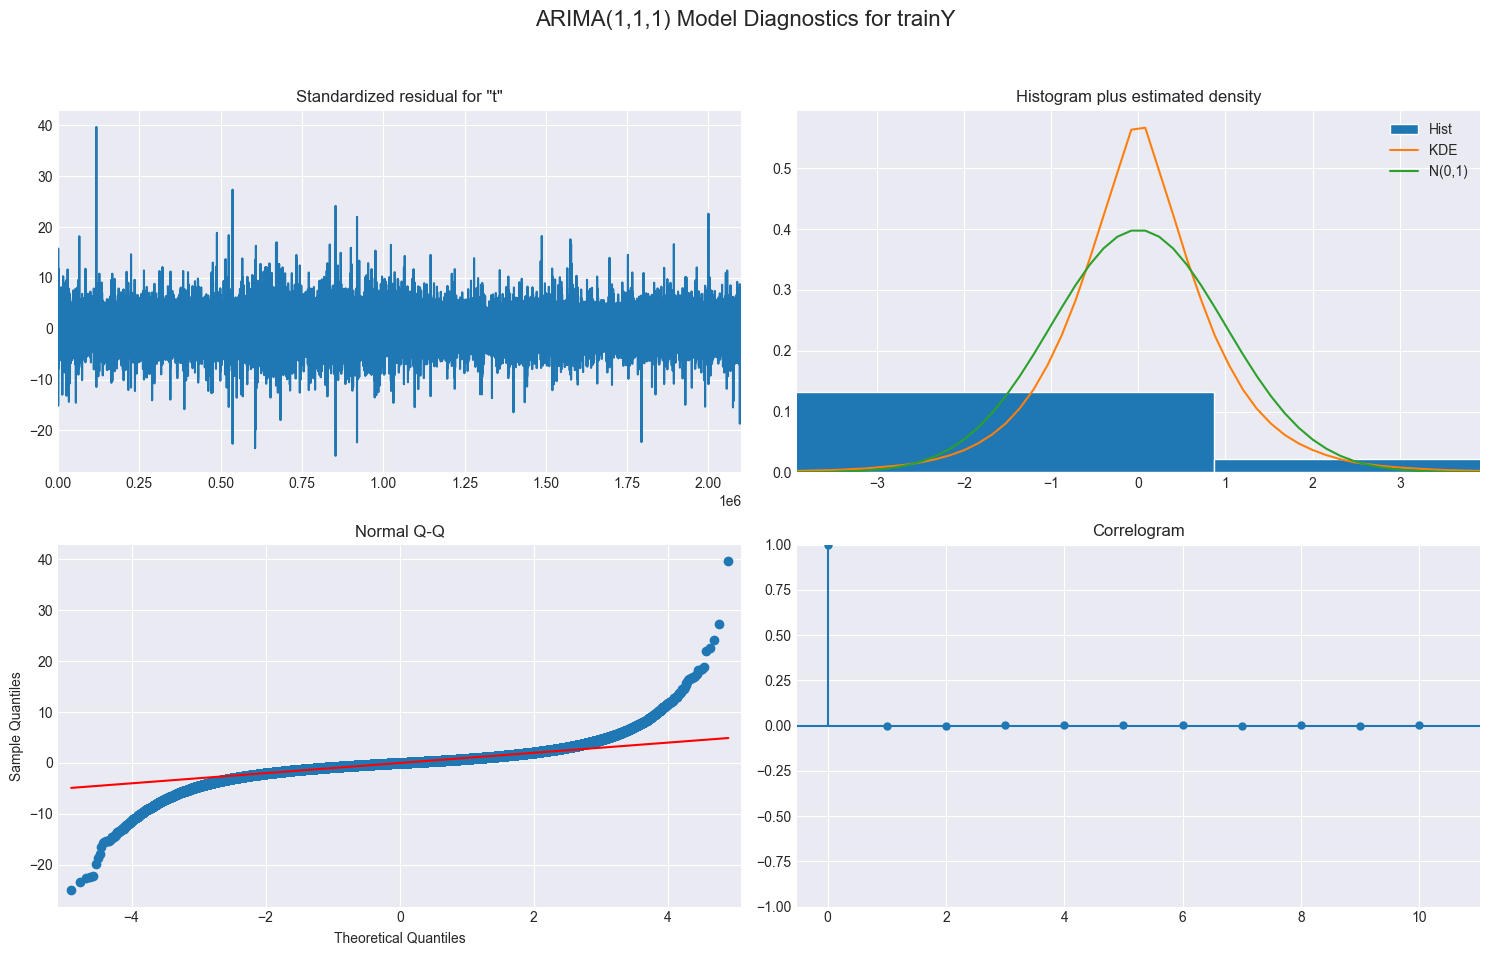

In [11]:
try:
    model = sm.tsa.SARIMAX(
        btc[TARGET_COLUMN],
        exog = btc[FEATURE_COLUMNS],
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False, maxiter=500)
    print(res.summary())

    fig = res.plot_diagnostics(figsize=(15, 10))
    fig.suptitle('ARIMA(1,1,1) Model Diagnostics for trainY', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to prevent title overlap
    plt.show()

except Exception as e:
    print("error, abort.")


测试集 RMSE: 100.565713
测试集 R²:   -0.0022


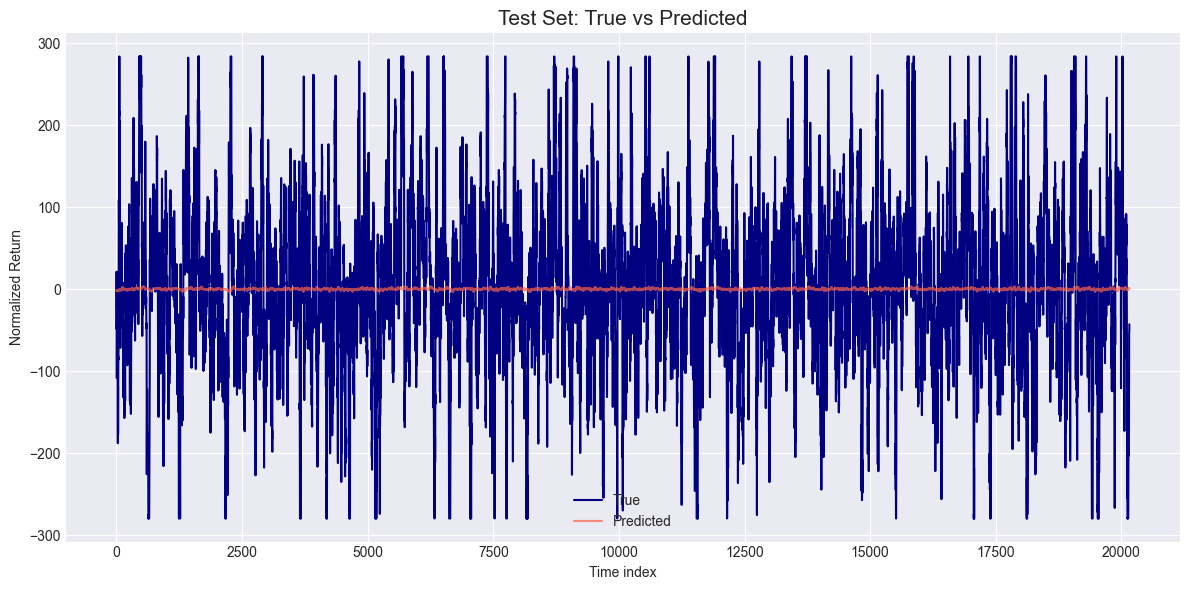

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

start = len(y_train_scaled)
end = start + len(y_val_scaled) - 1

y_pred = res.predict(start=start, end=end, exog=X_val_scaled)
y_pred = np.array(y_pred).ravel()[:len(y_val_scaled)]

# 3️⃣ RMSE、R²
rmse = mean_squared_error(y_val_scaled, y_pred) ** 0.5
r2 = r2_score(y_val_scaled, y_pred)
print(f"test set RMSE: {rmse:.6f}")
print(f"test set R²:   {r2:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_val_scaled, label='True', color='navy')
plt.plot(y_pred, label='Predicted', color='tomato', alpha=0.7)
plt.title('Test Set: True vs Predicted', fontsize=15)
plt.xlabel('Time index')
plt.ylabel('Normalized Return')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from signals_strategy import get_tanh_signal, backtest_strategy
print(y_pred)


n = len(y_pred)
# ---------- 2.  full_scaled， ----------
n_features = getattr(tp.scaler, "n_features_in_", None)
if n_features is None:
    n_features = tp.scaler.scale_.shape[0]

full_scaled = np.zeros((n, n_features), dtype=float)

#
target_norm_name = f"target_cum_return_{tp.window}m_norm"
if target_norm_name in target_cols:
    col_idx = target_cols.index(target_norm_name)
else:
    col_idx = 1 if n_features > 1 else 0
    print(f"Warning: {target_norm_name} not found, using column {col_idx}")

full_scaled[:, col_idx] = y_pred

# ---------- 3. RobustScaler ----------
unscaled_full = tp.scaler.inverse_transform(full_scaled)
unscaled_norm = unscaled_full[:, col_idx]  # log return

# ---------- 4. log return ----------
try:
    idx = btc_target.index[-n:]
    vol_slice = tp.volatility.loc[idx].values
except Exception:
    idx = btc_target.index[-n:] if hasattr(btc_target, 'index') else None
    vol_slice = tp.volatility.values[-n:]

cum_log_return = unscaled_norm * vol_slice

# ---------- 5. make index with time Series， ----------
if idx is not None:
    y_pred_inverse_series = pd.Series(cum_log_return, index=idx, name=f'pred_cum_log_return_{tp.window}m')
else:
    y_pred_inverse_series = pd.Series(cum_log_return, name=f'pred_cum_log_return_{tp.window}m')

# now y_pred_inverse_series  get_tanh_signal
print("done，Series top 10 row：")
print(y_pred_inverse_series.shape)
signal = get_tanh_signal(y_pred_inverse_series)
print(signal)

backtest_strategy(y_pred_inverse_series, y_val_seq)

[-1.72339481 -1.45541588 -1.14586676 ...  0.74834283  0.5574686
  0.71422739]
转换完成，Series 前 10 行：
(20160,)
⚡ 自动计算 Scale Factor: 410.04 (基于数据标准差)
------------------------------
Signal Range: [-1.0000, 1.0000]
Signal Mean:  0.0261
Signal Std:   0.5248
------------------------------
Timestamp
2025-08-31 19:58:00-04:00   -0.974854
2025-08-31 19:59:00-04:00   -0.950926
2025-08-31 20:00:00-04:00   -0.894859
2025-08-31 20:01:00-04:00   -0.880336
2025-08-31 20:02:00-04:00   -0.947833
                               ...   
2025-09-14 19:53:00-04:00    0.518967
2025-09-14 19:54:00-04:00    0.593826
2025-09-14 19:55:00-04:00    0.529438
2025-09-14 19:56:00-04:00    0.414142
2025-09-14 19:57:00-04:00    0.511942
Name: pred_cum_log_return_30m, Length: 20160, dtype: float64


⚡ 自动计算 Scale Factor: 410.04 (基于数据标准差)
------------------------------
Signal Range: [-1.0000, 1.0000]
Signal Mean:  0.0261
Signal Std:   0.5248
------------------------------


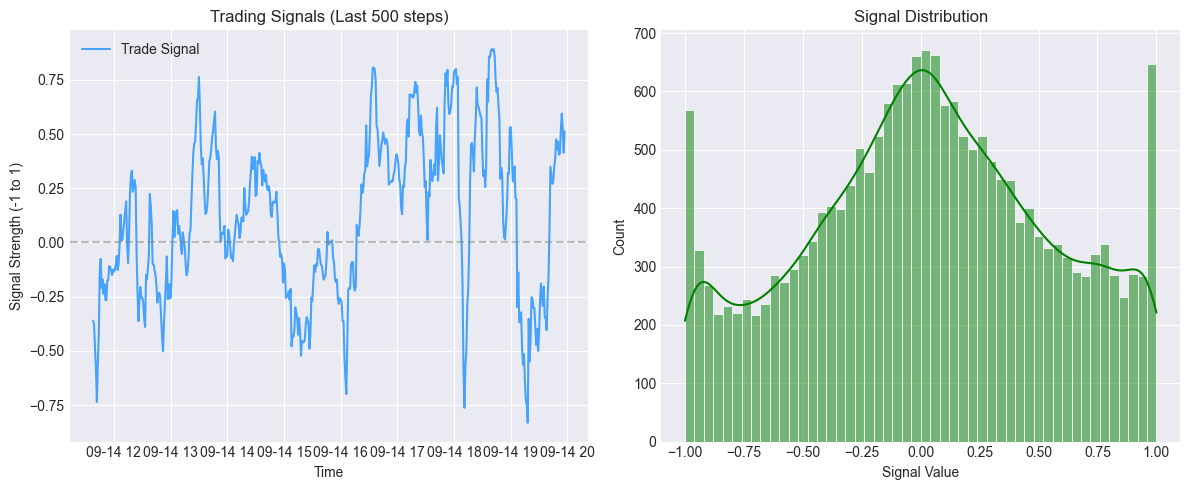

✅ 测试数据已对齐:
  - 预测信号长度: 20160
  - 真实收益长度: 20160
  - 测试时长: 14.00 天

📊 Strategy Performance Comparison (Last 2 Days)
Metric                 | Ideal (No Cost)    | Aggressive (T=0)   | Conservative (T=0.3)
-------------------------------------------------------------------------------------
Total Return (B&H)     | 6.51%              | 6.51%              | 6.51%             
Total Return (Strat)   | 4.81%              | 5.02%              | -6.68%            
Sharpe Ratio           | 6.53               | 6.83               | -10.28            
Sortino Ratio          | 7.25               | 6.73               | -8.04             
Max Drawdown           | -2.23%             | -1.99%             | -9.17%            
Trade Count            | 20160              | 15435              | 6880              
Cost Rate              | 0.00%              | 0.00%              | 0.01%             


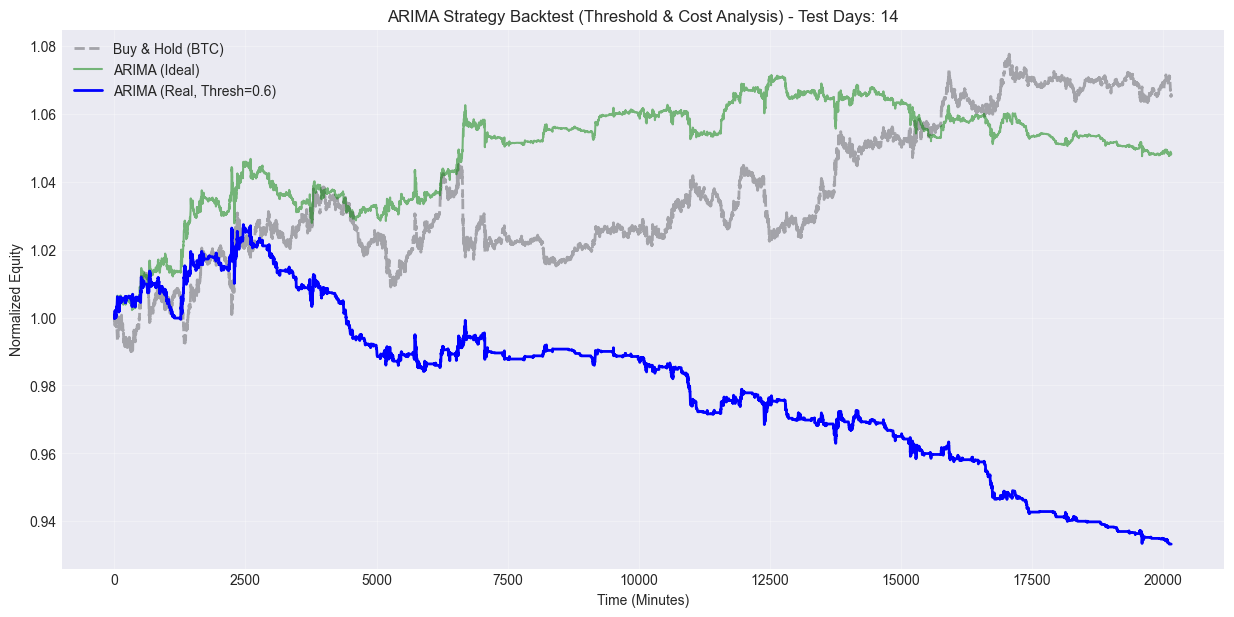

In [21]:
signals = get_tanh_signal(y_pred_inverse_series)  # !!!!


plt.figure(figsize=(12, 5))

# signal with time
plt.subplot(1, 2, 1)
plt.plot(signals[-500:], label='Trade Signal', color='dodgerblue', alpha=0.8)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title(f"Trading Signals (Last 500 steps)")
plt.ylabel("Signal Strength (-1 to 1)")
plt.xlabel("Time")
plt.legend()

# signal distributions
plt.subplot(1, 2, 2)
sns.histplot(signals, bins=50, kde=True, color='green')
plt.title("Signal Distribution")
plt.xlabel("Signal Value")
plt.xlim(-1.1, 1.1)

plt.tight_layout()
plt.show()

""" ================================================================================"""


num_test_samples = len(signals)


real_step_returns = btc['target_log_return'].iloc[-num_test_samples:].values


real_step_returns = np.nan_to_num(real_step_returns)

print(f"✅ test data prepared:")
print(f"  - predict signal length: {len(signals)}")
print(f"  - actual return length: {len(real_step_returns)}")
print(f"  - testing steps: {len(signals) / 60 / 24:.2f} days")

# ==============================================================================
# 3. Execution
# ==============================================================================


res_conservative = backtest_strategy(signals, real_step_returns, threshold=0.6, cost_rate=0.0001)


res_ideal = backtest_strategy(signals, real_step_returns, threshold=0.0, cost_rate=0.0)

res_aggressive = backtest_strategy(signals, real_step_returns, threshold=0.2, cost_rate=0.0)


print("\n📊 Strategy Performance Comparison (Last 2 Days)")
print("=" * 85)
print(f"{'Metric':<22} | {'Ideal (No Cost)':<18} | {'Aggressive (T=0)':<18} | {'Conservative (T=0.3)':<18}")
print("-" * 85)


metrics_keys = res_ideal['metrics'].keys()
for k in metrics_keys:
    v1 = res_ideal['metrics'][k]
    v2 = res_aggressive['metrics'][k]
    v3 = res_conservative['metrics'][k]
    print(f"{k:<22} | {v1:<18} | {v2:<18} | {v3:<18}")
    print("=" * 85)


plt.figure(figsize=(15, 7))
plt.plot(res_ideal['equity_bh'], label='Buy & Hold (BTC)', color='black', alpha=0.3, linewidth=2, linestyle='--')
plt.plot(res_ideal['equity_strat'], label='ARIMA (Ideal)', color='green', alpha=0.5)
plt.plot(res_conservative['equity_strat'], label='ARIMA (Real, Thresh=0.6)', color='blue', linewidth=2)

plt.title(f'ARIMA Strategy Backtest (Threshold & Cost Analysis) - Test Days: {TEST_DAYS}')
plt.ylabel('Normalized Equity')
plt.xlabel('Time (Minutes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
import os
print(os.getcwd())


signals = get_tanh_signal(y_pred_inverse_series)
df = pd.DataFrame({
    'signal': signals,
    'real_step_return': real_step_returns,
    'equity_strat': res_ideal['equity_strat'],
    'equity_bh': res_ideal['equity_bh']
})

df.to_csv("backtest_data.csv", index=False)


/Users/tingrui/Downloads/bitcoin
⚡ 自动计算 Scale Factor: 410.04 (基于数据标准差)
------------------------------
Signal Range: [-1.0000, 1.0000]
Signal Mean:  0.0261
Signal Std:   0.5248
------------------------------
